# Use NUPACK+BO to predict and optimize eq fractions of bound sticky ends

NUPACK is used to predict bound fractions of sticky ends

Bayesian optimization with BoTorch is used to update the conditions that are evaluated in NUPACK

Sodium: Monovalent ions range: [0.05-1.1]M

Magnesium: Divalent ions range: [0.0-0.2]M

# Import

In [1]:
from nupack import *
from __future__ import annotations

import math
import random
from dataclasses import dataclass
from typing import Tuple, Optional, Dict

import numpy as np
import torch
from botorch.models import SingleTaskGP
from botorch.models.transforms import Normalize, Standardize
from botorch.fit import fit_gpytorch_mll
from botorch.acquisition import qExpectedImprovement,qLogExpectedImprovement
from botorch.optim import optimize_acqf
from gpytorch.mlls import ExactMarginalLogLikelihood
import matplotlib
import matplotlib.pyplot as plt

## test nupack prediction with tube tool for conrad et al sticky end design

In [2]:
# Define physical model
my_model = Model(material='dna', celsius=20,sodium=0.15,magnesium=0.0)

# Define strand species
a = Strand('CGATCG', name='a')
b = ~a

# Define tube ensemble containing strands at specified concentrations 
# interacting to form all complexes up to 4 strands
t1 = Tube(strands={a:1960e-6}, complexes=SetSpec(max_size=2), name='Tube t1')

# Analyze the tube ensemble
# Calculate pfunc (default), pairs, mfe, concentration (default) for each complex 
# Since pairs is specified, calculate ensemble pair fractions for the tube ensemble
tube_result = tube_analysis(tubes=[t1], compute=['pairs', 'mfe'], model=my_model)
tube_result

Result(tubes={<Tube Tube t1>: <nupack.analysis.TubeResult object at 0x7b8b2039f0a0>}, complexes=<nupack.analysis.ComplexDict object at 0x7b8b2039f610>)

## test nupack prediction using target tube feature

In [3]:
# Define physical model
my_model = Model(material='dna', celsius=20,sodium=0.15)

#Define sequence domains
d=Domain("N6",name="d")

#Define strand containing these domains
sd=TargetStrand([d],name="sd")

#Define a target complex

hybr_se=TargetComplex([sd,sd],"((((((+))))))")
tube_hybr_se=TargetTube(on_targets={hybr_se:1e-06},off_targets=SetSpec(max_size=2),name="tube_hybr_se")

# Set a stop condition of 1% and a seed for random number generation to get a reproducible result for this demo
my_options = DesignOptions(f_stop=0.01, seed=93)

# Define and run the test tube design job
my_design = tube_design(tubes=[tube_hybr_se], model=my_model, options=my_options)
my_results = my_design.run(trials=1)[0]

# Display the design results
my_results

<DesignResult: defect=0.134448>

## use tool to predict se sequences

In [6]:

def design_palindromic_sticky_end(
    L=6,
    celsius=20,
    sodium=0.15,      # M
    magnesium=0.0,    # M (set if needed, e.g., 0.012 for 12 mM Mg2+)
    C_tot=1e-6,       # total sticky ends (M)
    frac_bound=0.6,   # desired fraction of sticky ends that are duplexed
    seed=93,
    f_stop=0.01,  # stop a trial when defect ≤ 1%
    trials=1
):
    # Physical model
    model = Model(material='dna', celsius=celsius, sodium=sodium, magnesium=magnesium)

    # One domain for a single sticky end; L nt, designable
    d = Domain('N' * L, name='d')

    # One strand species for the sticky end
    sd = TargetStrand([d], name='sd')

    # On-target complexes: monomer and homodimer
    monomer = TargetComplex([sd], '.' * L, name='A')  # unpaired monomer
    dimer   = TargetComplex([sd, sd], '(' * L + '+' + ')' * L, name='AA')  # perfect duplex AA

    # Translate fraction → target concentrations
    D = frac_bound * C_tot / 2.0
    A = C_tot - 2.0 * D
    if A < 0:
        raise ValueError(f"Requested fraction {frac_bound} is infeasible for C_tot={C_tot:g} M")

    # Target tube: ask for A and AA at these concentrations
    tube = TargetTube(
        on_targets={monomer: A, dimer: D},
        off_targets=SetSpec(max_size=2),  # only allow up to dimers
        name='tube_pal'
    )

    options = DesignOptions(f_stop=f_stop, seed=seed)
    job = tube_design(tubes=[tube], model=model, options=options)
    result = job.run(trials=trials)[0]
    return result



def design_nonpalindromic_sticky_ends(
    L=6,
    celsius=20,
    sodium=0.15,
    magnesium=0.0,
    C_A=1e-6,        # total concentration of A
    C_B=1e-6,        # total concentration of B
    frac_bound_A=0.6,  # fraction of A that should be in AB
    seed=93,
    f_stop=0.01,
    trials=1
):
    if frac_bound_A < 0 or frac_bound_A > 1:
        raise ValueError("frac_bound_A must be between 0 and 1")

    # Physical model
    model = Model(material='dna', celsius=celsius, sodium=sodium, magnesium=magnesium)

    # One designable domain; B uses the complement of A's domain
    d = Domain('N' * L, name='d')
    A = TargetStrand([d], name='A')
    B = TargetStrand([~d], name='B')  # enforce complementarity by construction

    # Target complexes: monomers and the AB duplex
    monA = TargetComplex([A], '.' * L, name='A_mono')
    monB = TargetComplex([B], '.' * L, name='B_mono')
    AB   = TargetComplex([A, B], '(' * L + '+' + ')' * L, name='AB')

    # Translate fraction → concentrations
    AB_target = frac_bound_A * C_A
    if AB_target > min(C_A, C_B):
        raise ValueError(f"Requested AB={AB_target:g} M exceeds min(C_A, C_B)={min(C_A, C_B):g} M")
    A_free = C_A - AB_target
    B_free = C_B - AB_target

    tube = TargetTube(
        on_targets={monA: A_free, monB: B_free, AB: AB_target},
        off_targets=SetSpec(max_size=2),
        name='tube_AB'
    )

    options = DesignOptions(f_stop=f_stop, seed=seed)
    job = tube_design(tubes=[tube], model=model, options=options)
    result = job.run(trials=trials)[0]
    return result


In [7]:
# Example run
res_pal = design_palindromic_sticky_end(L=6, celsius=22, sodium=1, C_tot=1e-6, frac_bound=0.6)
res_pal

<DesignResult: defect=0.087772>

In [8]:
# Example run
res_ab = design_nonpalindromic_sticky_ends(
    L=6, celsius=20, sodium=0.15,
    C_A=1e-6, C_B=1e-6, frac_bound_A=0.6
)
res_ab

<DesignResult: defect=0.046454>

## Use NUPACK's tube prediction in combination with BO to predict a sequence design and coniditions, given a target fraction of bound sticky ends

In [3]:
#code developed using Copilot
#bases and their complement
BASES = np.array(['A', 'C', 'G', 'T'])
COMP = {'A': 'T', 'T': 'A', 'C': 'G', 'G': 'C'}

#convert bases into float values
def num_to_base(u: float) -> str:
    """Map a scalar in [0,1] to a base via quartiles."""
    if u < 0.25:   return 'A'
    if u < 0.50:   return 'C'
    if u < 0.75:   return 'G'
    return 'T'

#get reverse complement
def revcomp(seq: str) -> str:
    return ''.join(COMP[b] for b in seq[::-1])
    
#convert hybpercube into DNA sequence 
def decode_sequence(z: np.ndarray, length: int, palindromic: bool) -> str:
    """
    Decode a real vector in [0,1]^k into a DNA sequence.
    If palindromic=True, k=length/2 (length must be even) and we mirror-complement.
    Else, k=length.
    """
    if palindromic:
        if length % 2 != 0:
            raise ValueError("Palindromic sticky ends require an even length.")
        half = ''.join(num_to_base(x) for x in z)                # length/2
        seq = half + revcomp(half)                               # full palindrome
    else:
        seq = ''.join(num_to_base(x) for x in z)                 # length
    return seq


@dataclass
class NupackSettings:
    a0: float = 1e-6          # initial molar concentration (A, B), M
    b0: float = 1e-6
    material: str = 'dna'
    ensemble: str = 'stacking'  # default in NUPACK 4

def nupack_fraction_bound(palindromic:bool,
                          seqA: str,
                          temp_c: float,
                          na_M: float,
                          mg_M: float,
                          complex_bonus:list,                
                          settings: NupackSettings = NupackSettings()) -> float:
    """
    Compute equilibrium fraction bound of A·B using NUPACK tube analysis.
    
    """
    # Build complementary strand
    seqB = revcomp(seqA)

    # Model with T/ions (NUPACK 4)
    model = Model(material=settings.material,
                  ensemble=settings.ensemble,
                  celsius=float(temp_c),
                  sodium=float(na_M),
                  magnesium=float(mg_M))  # c.f. NUPACK Model spec
    # Define strands and the dimer complex
    A = Strand(seqA, name='A')
    B = Strand(seqB, name='B')
    AB = Complex([A, B], name='AB',bonus=complex_bonus[0])
    BB = Complex([B, B], name='AB',bonus=complex_bonus[2])
    AA = Complex([A, A], name='AB',bonus=complex_bonus[1])

    # Test tube with monomers + dimer up to 2 strands
    tube = Tube(
        strands={A: settings.a0, B: settings.b0},
        complexes=SetSpec(max_size=2, include=[AB,BB,AA]),
        name='tube'
    )

    # Analyze equilibrium concentrations
    result = tube_analysis(tubes=[tube], model=model)  # NUPACK test-tube analysis
    if palindromic==False:
        # Extract [AB]
        #AB_conc = float(result.tubes[tube].concentrations[AB])
        AB_conc = float(result.tubes[tube].complex_concentrations[AB])
        frac = AB_conc / min(settings.a0, settings.b0)
    if palindromic==True:
        #all would be two hyrbidized sticky ends
        AB_conc = float(result.tubes[tube].complex_concentrations[AB])
        BB_conc = float(result.tubes[tube].complex_concentrations[BB])
        AA_conc = float(result.tubes[tube].complex_concentrations[AA])

        frac = (AB_conc+BB_conc+AA_conc) / min(settings.a0, settings.b0)
    
    return max(0.0, min(1.0, frac))

# --------------------------
# Bayesian optimization wrapper
# --------------------------

@dataclass
class BOConfig:
    n_init: int = 12           # initial Sobol/random points
    n_iter: int = 50           # BO iterations
    num_restarts: int = 10     # restarts for acquisition optimization
    raw_samples: int = 128     # init samples for restart heuristic
    seed: int=1 #random seed to use during optimisation, each round will get seed+len(Y_train) as seed
    dtype: torch.dtype = torch.double
    device: torch.device = torch.device('cpu')

#get bounds for bayesian opt
def build_bounds(length: int,
                 palindromic: bool,
                 T_range: Tuple[float, float],
                 Na_range: Tuple[float, float],
                 Mg_range: Tuple[float, float]) -> torch.Tensor:
    """
    Create a [2 x d] bounds tensor for BoTorch.
    Decision vars: [T, Na, Mg, z_1 .. z_k] with z in [0,1].
    """
    k = (length // 2) if palindromic else length
    lowers = [T_range[0], Na_range[0], Mg_range[0]] + [0.0] * k
    uppers = [T_range[1], Na_range[1], Mg_range[1]] + [1.0] * k
    return torch.tensor([lowers, uppers], dtype=torch.double)

def decode_candidate(x: torch.Tensor,
                     length: int,
                     palindromic: bool) -> Tuple[float, float, float, str]:
    """Split candidate into (T, Na, Mg, seqA)."""
    x = x.detach().cpu().numpy()
    T, Na, Mg = float(x[0]), float(x[1]), float(x[2])
    z = x[3:]
    seqA = decode_sequence(z, length=length, palindromic=palindromic)
    return T, Na, Mg, seqA

def bo_optimize_sticky(
    target_fraction: float,
    T_range: Tuple[float, float],
    Na_range: Tuple[float, float],
    Mg_range: Tuple[float, float],
    length: int,
    palindromic: bool,
    complex_bonus:list,
    settings: Optional[NupackSettings] = None,
    bo: BOConfig = BOConfig()
) -> Dict[str, object]:
    """
    Run BO over [T, Na, Mg, sequence] to minimize squared error to target fraction.

    Returns dict with best design and its measured fraction.
    """
    settings = settings or NupackSettings()

    # Decision space
    bounds = build_bounds(length, palindromic, T_range, Na_range, Mg_range).to(bo.device, bo.dtype)
    d = bounds.shape[1]
    #print(bounds)

    # Initial design (Sobol-like random)
    torch.manual_seed(bo.seed)
    np.random.seed(bo.seed)
    train_X = bounds[0] + (bounds[1] - bounds[0]) * torch.rand(bo.n_init, d, dtype=bo.dtype, device=bo.device)
    #print(train_X)
    def eval_points(X: torch.Tensor) -> (torch.Tensor,torch.Tensor):
        ys = []
        frac_l=[]
        for x in X:
            T, Na, Mg, seqA = decode_candidate(x, length, palindromic)
            try:
                frac = nupack_fraction_bound(palindromic, seqA, T, Na, Mg, complex_bonus, settings=settings)
            except Exception:
                frac = 0.0  # penalize failed evaluations
            # maximize negative squared error
            #y = -(frac - target_fraction) ** 2
            #y=1/(1+(frac - target_fraction) ** 2)
            y=1/(1+np.sqrt((frac - target_fraction) ** 2))

            ys.append([y])
            frac_l.append([frac])
        return torch.tensor(ys, dtype=bo.dtype, device=bo.device),torch.tensor(frac_l, dtype=bo.dtype, device=bo.device)

    # Evaluate initial data
    train_Y,frac_train = eval_points(train_X)

    # BO loop
    best_y, best_x = train_Y.max(dim=0).values.item(), train_X[train_Y.argmax()].clone()

    for it in range(bo.n_iter):
        print(it+1,"/",bo.n_iter)
        #set seed
        torch.manual_seed(bo.seed+len(train_Y)+bo.n_init)
        np.random.seed(bo.seed+len(train_Y)+bo.n_init)
        # Fit GP
        
        d = train_X.shape[-1]
        
        # Make sure Y has an explicit output dimension n×m
        # (SingleTaskGP works with m=1 or multi-output m>1)
        if train_Y.dim() == 1:
            train_Y = train_Y.view(-1, 1)
        m = train_Y.shape[-1]

        model = SingleTaskGP(train_X, train_Y,input_transform=Normalize(d=d),outcome_transform=Standardize(m=m))
        mll = ExactMarginalLogLikelihood(model.likelihood, model)
        fit_gpytorch_mll(mll)

        # Acquisition (qEI, q=1)
        acq = qLogExpectedImprovement(model=model, best_f=train_Y.max().item())

        # Optimize acquisition over bounds
        candidate, _ = optimize_acqf(
            acq_function=acq,
            bounds=bounds,
            q=1,
            num_restarts=bo.num_restarts,
            raw_samples=bo.raw_samples,
        )  # standard BoTorch pattern

        # Evaluate candidate
        Y_new ,frac_new= eval_points(candidate)

        # Append data
        train_X = torch.cat([train_X, candidate], dim=0)
        train_Y = torch.cat([train_Y, Y_new], dim=0)
        frac_train=torch.cat([frac_train, frac_new], dim=0)

        # Track best
        if Y_new.item() > best_y:
            best_y = Y_new.item()
            best_x = candidate[0].clone()

    # Decode the best
    T_best, Na_best, Mg_best, seq_best = decode_candidate(best_x, length, palindromic)
    frac_best = nupack_fraction_bound(palindromic,seq_best, T_best, Na_best, Mg_best, complex_bonus, settings=settings)

    return {
        "best_sequence": seq_best,
        "best_temperature_c": T_best,
        "best_Na_M": Na_best,
        "best_Mg_M": Mg_best,
        "best_fraction": frac_best,
        "squared_error": (frac_best - target_fraction) ** 2,
        "history_n": len(train_Y),
        "fitness":train_Y,
        "frac_candidates":frac_train,
        "candidates":train_X
    }



## test method

In [20]:
%%time
res = bo_optimize_sticky(
        target_fraction=0.8,
        T_range=(10.0, 60.0),
        Na_range=(0.01, 0.5),
        Mg_range=(0.0, 0.02),
        length=8,
        palindromic=False,
        complex_bonus=[0,0,0],
        settings=NupackSettings(a0=1e-6, b0=1e-6),
        bo=BOConfig(n_init=50,n_iter=50,seed=1,device=torch.device('cpu')))


1 / 50
2 / 50
3 / 50
4 / 50
5 / 50
6 / 50
7 / 50
8 / 50
9 / 50
10 / 50
11 / 50
12 / 50
13 / 50
14 / 50
15 / 50
16 / 50
17 / 50
18 / 50
19 / 50
20 / 50
21 / 50
22 / 50
23 / 50
24 / 50
25 / 50
26 / 50
27 / 50
28 / 50
29 / 50
30 / 50
31 / 50
32 / 50
33 / 50
34 / 50
35 / 50
36 / 50
37 / 50
38 / 50
39 / 50
40 / 50
41 / 50
42 / 50
43 / 50
44 / 50
45 / 50
46 / 50
47 / 50
48 / 50
49 / 50
50 / 50
CPU times: user 15min 15s, sys: 720 ms, total: 15min 15s
Wall time: 1min 36s


In [32]:
print(res["best_sequence"])
print(res["best_temperature_c"])
print(res["best_Na_M"])
print(res["best_Mg_M"])
print(res["best_fraction"])

GAAGGCTC
25.780538212418218
0.26049408489338505
0.02
0.7966204712880518


tensor(51)


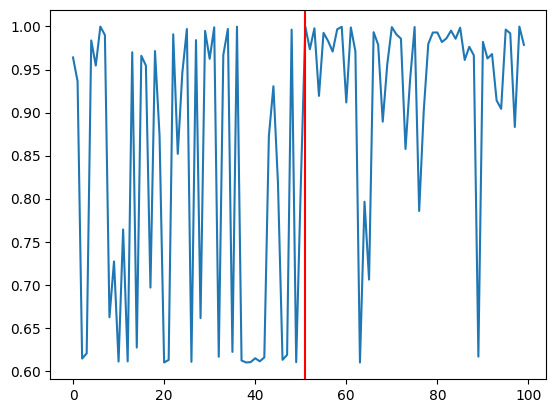

In [24]:
plt.plot(res["fitness"].cpu())
plt.axvline(np.argmax(res["fitness"].cpu()),color="red")
print(np.argmax(res["fitness"].cpu()))

In [25]:
# Define physical model
my_model = Model(material='dna',  celsius=res["best_temperature_c"],sodium=res["best_Na_M"],magnesium=res["best_Mg_M"])

# Define strand species
a = Strand(res["best_sequence"], name='a')
b = ~a

# Define tube ensemble containing strands at specified concentrations 
# interacting to form all complexes up to 4 strands
t1 = Tube(strands={a:1e-6, b:1e-6}, complexes=SetSpec(max_size=2), name='Tube t1')

# Analyze the tube ensemble
# Calculate pfunc (default), pairs, mfe, concentration (default) for each complex 
# Since pairs is specified, calculate ensemble pair fractions for the tube ensemble
tube_result = tube_analysis(tubes=[t1], compute=['pairs', 'mfe'], model=my_model)
tube_result

Result(tubes={<Tube Tube t1>: <nupack.analysis.TubeResult object at 0x761b0c45f490>}, complexes=<nupack.analysis.ComplexDict object at 0x761b0c2d19f0>)

In [3]:
res2 = bo_optimize_sticky(
        target_fraction=0.8,
        T_range=(10, 60.0),
        Na_range=(0.05, 0.5),
        Mg_range=(0.0, 0.0),
        length=6,
        palindromic=True,
        complex_bonus=[0,0,0],
        settings=NupackSettings(a0=0.5e-6, b0=0.5e-6),
        bo=BOConfig(n_init=50,n_iter=50,seed=1,device=torch.device('cpu')))

1 / 50
2 / 50
3 / 50
4 / 50
5 / 50
6 / 50
7 / 50
8 / 50
9 / 50
10 / 50
11 / 50
12 / 50
13 / 50
14 / 50
15 / 50
16 / 50
17 / 50
18 / 50
19 / 50
20 / 50
21 / 50
22 / 50
23 / 50
24 / 50
25 / 50
26 / 50
27 / 50
28 / 50
29 / 50
30 / 50
31 / 50
32 / 50
33 / 50
34 / 50
35 / 50
36 / 50
37 / 50
38 / 50
39 / 50
40 / 50
41 / 50
42 / 50
43 / 50
44 / 50
45 / 50
46 / 50
47 / 50
48 / 50
49 / 50
50 / 50


In [4]:
print(res2["best_sequence"])
print(res2["best_temperature_c"])
print(res2["best_Na_M"])
print(res2["best_Mg_M"])
print(res2["best_fraction"])

TGCGCA
17.997427298889136
0.37926039735030637
0.0
0.7960222539731447


tensor(72)


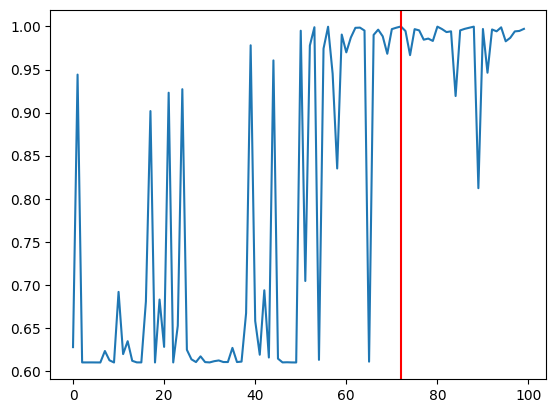

In [5]:
plt.plot(res2["fitness"].cpu())
plt.axvline(np.argmax(res2["fitness"].cpu()),color="red")
print(np.argmax(res2["fitness"].cpu()))

In [6]:
# Define physical model
my_model = Model(material='dna',  celsius=res2["best_temperature_c"],sodium=res2["best_Na_M"],magnesium=res2["best_Mg_M"])

# Define strand species
a = Strand(res2["best_sequence"], name='a')
#b = ~a

# Define tube ensemble containing strands at specified concentrations 
# interacting to form all complexes up to 4 strands
t1 = Tube(strands={a:1e-6}, complexes=SetSpec(max_size=2), name='Tube t1')

# Analyze the tube ensemble
# Calculate pfunc (default), pairs, mfe, concentration (default) for each complex 
# Since pairs is specified, calculate ensemble pair fractions for the tube ensemble
tube_result = tube_analysis(tubes=[t1], compute=['pairs', 'mfe'], model=my_model)
tube_result

Result(tubes={<Tube Tube t1>: <nupack.analysis.TubeResult object at 0x71172815f220>}, complexes=<nupack.analysis.ComplexDict object at 0x71172815e320>)

## conditions conrad et al 

In [4]:
%%time
res3 = bo_optimize_sticky(
        target_fraction=0.609,
        T_range=(15, 30),  #(15,25)
        Na_range=(0.05, 0.2), #(0.05,0.2)
        Mg_range=(0.0, 0.0),
        length=6,
        palindromic=True,
        complex_bonus=[0,0,0],
        settings=NupackSettings(a0=980e-6, b0=980e-6),
        bo=BOConfig(n_init=100,n_iter=300,seed=1,device=torch.device('cpu')))

1 / 300
2 / 300
3 / 300
4 / 300
5 / 300
6 / 300
7 / 300
8 / 300
9 / 300
10 / 300
11 / 300
12 / 300
13 / 300
14 / 300
15 / 300
16 / 300
17 / 300
18 / 300
19 / 300
20 / 300
21 / 300
22 / 300
23 / 300
24 / 300
25 / 300
26 / 300
27 / 300
28 / 300
29 / 300
30 / 300
31 / 300
32 / 300
33 / 300
34 / 300
35 / 300
36 / 300
37 / 300
38 / 300
39 / 300
40 / 300
41 / 300
42 / 300
43 / 300
44 / 300
45 / 300
46 / 300
47 / 300
48 / 300
49 / 300
50 / 300
51 / 300
52 / 300
53 / 300
54 / 300
55 / 300
56 / 300
57 / 300
58 / 300
59 / 300
60 / 300
61 / 300
62 / 300
63 / 300
64 / 300
65 / 300
66 / 300
67 / 300
68 / 300
69 / 300
70 / 300
71 / 300
72 / 300
73 / 300
74 / 300
75 / 300
76 / 300
77 / 300
78 / 300
79 / 300
80 / 300
81 / 300
82 / 300
83 / 300
84 / 300
85 / 300
86 / 300
87 / 300
88 / 300
89 / 300
90 / 300
91 / 300
92 / 300
93 / 300
94 / 300
95 / 300
96 / 300
97 / 300
98 / 300
99 / 300
100 / 300
101 / 300
102 / 300
103 / 300
104 / 300
105 / 300
106 / 300
107 / 300
108 / 300
109 / 300
110 / 300
111 / 30

In [5]:
print(res3["best_sequence"])
print(res3["best_temperature_c"])
print(res3["best_Na_M"])
print(res3["best_Mg_M"])
print(res3["best_fraction"])

ACTAGT
28.77691431082155
0.19236354454240281
0.0
0.6093253431418268


tensor(244)


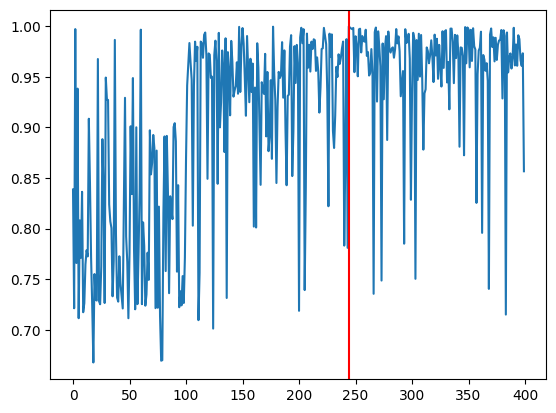

In [6]:
plt.plot(res3["fitness"].cpu())
plt.axvline(np.argmax(res3["fitness"].cpu()),color="red")
print(np.argmax(res3["fitness"].cpu()))

In [7]:
# Define physical model
my_model = Model(material='dna',  celsius=res3["best_temperature_c"],sodium=res3["best_Na_M"],magnesium=res3["best_Mg_M"])

# Define strand species
a = Strand(res3["best_sequence"], name='a')
#b = ~a

# Define tube ensemble containing strands at specified concentrations 
# interacting to form all complexes up to 4 strands
t1 = Tube(strands={a:1960e-6}, complexes=SetSpec(max_size=2), name='Tube t1')

# Analyze the tube ensemble
# Calculate pfunc (default), pairs, mfe, concentration (default) for each complex 
# Since pairs is specified, calculate ensemble pair fractions for the tube ensemble
tube_result = tube_analysis(tubes=[t1], compute=['pairs', 'mfe'], model=my_model)
tube_result

Result(tubes={<Tube Tube t1>: <nupack.analysis.TubeResult object at 0x7b89215bdae0>}, complexes=<nupack.analysis.ComplexDict object at 0x7b89215beaa0>)

In [52]:
res3["candidates"]

tensor([[15.9158,  0.0837,  0.0000,  0.1771,  0.5561,  0.1094],
        [21.9137,  0.1563,  0.0000,  0.4967,  0.5104,  0.3295],
        [25.7731,  0.1077,  0.0000,  0.1175,  0.6402,  0.1968],
        ...,
        [18.8300,  0.1523,  0.0000,  1.0000,  0.2539,  0.8447],
        [16.3062,  0.1815,  0.0000,  1.0000,  0.2407,  0.8591],
        [28.8854,  0.0839,  0.0000,  0.7234,  0.4353,  0.9620]],
       dtype=torch.float64)

In [8]:

num_top=40
top_candidate_ids=np.array([e[0] for e in res3["fitness"]]).argsort()[-num_top:][::-1]
print(top_candidate_ids)

for i in top_candidate_ids:
    
    print(decode_candidate(res3["candidates"][i],8,True),"fraction bound SE:",res3["frac_candidates"][i])


[244 177 147 347 245 349 268 202 390 222 248 150 354 246 370 335 334 254
 286   2 247 204 294 253 350  60 259 352 379 330 381 327 270 329 279 361
 267 384 117 301]
(28.77691431082155, 0.19236354454240281, 0.0, 'ACTAGT') fraction bound SE: tensor([0.6093], dtype=torch.float64)
(20.637215119228838, 0.1311132106146604, 0.0, 'GAATTC') fraction bound SE: tensor([0.6095], dtype=torch.float64)
(29.656535581636746, 0.12649638748650108, 0.0, 'TGTACA') fraction bound SE: tensor([0.6097], dtype=torch.float64)
(25.100379750449, 0.2, 0.0, 'CAATTG') fraction bound SE: tensor([0.6099], dtype=torch.float64)
(28.780589421601746, 0.190180316374982, 0.0, 'ACTAGT') fraction bound SE: tensor([0.6077], dtype=torch.float64)
(25.650183069158867, 0.1038070815586978, 0.0, 'AGATCT') fraction bound SE: tensor([0.6103], dtype=torch.float64)
(24.73815407247119, 0.08476055736521827, 0.0, 'AGATCT') fraction bound SE: tensor([0.6076], dtype=torch.float64)
(28.615728327199555, 0.18349937040916978, 0.0, 'ACTAGT') fracti

array([ 60, 120, 160])

In [23]:
res3["candidates"].argsort()

tensor([[2, 1, 5, 3, 4, 0],
        [2, 1, 5, 3, 4, 0],
        [2, 1, 3, 5, 4, 0],
        ...,
        [2, 3, 5, 1, 4, 0],
        [2, 4, 5, 1, 3, 0],
        [2, 5, 1, 4, 3, 0]])